# Module 2: Data Manipulation and Cleaning

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Work confidently with vectors, matrices, lists, and data frames
- Import and inspect data sets in R
- Wrangle data using dplyr verbs
- Reshape data between wide and long formats using tidyr
- Detect and handle missing values and outliers
- Perform data transformation and basic feature engineering

## 1. Working with Vectors, Matrices, Lists, and Data Frames

R has several core data structures. Understanding when to use each one is fundamental to working effectively with data.

- **Vector**: an ordered collection of values of the same type (1 dimensional)
- **Matrix**: a 2 dimensional collection of values of the same type
- **List**: an ordered collection that can hold different types and structures
- **Data frame**: a table like structure where each column can be a different type - the main structure used for data analysis


In [1]:
# ---- Vectors ----
ages <- c(25, 30, 35, 40)
names_vec <- c("Ada", "Bola", "Chika", "Dele")
ages[2]            # access second element
ages[ages > 28]     # logical indexing

# ---- Matrices ----
mat <- matrix(1:9, nrow = 3, ncol = 3)
mat
mat[2, 3]           # row 2, column 3
t(mat)              # transpose

# ---- Lists ----
person <- list(name = "Ada", age = 25, scores = c(80, 90, 85))
person$name
person[["scores"]]

# ---- Data frames ----
df <- data.frame(name = names_vec, age = ages, stringsAsFactors = FALSE)
df
str(df)
nrow(df); ncol(df)


[1] 30

[1] 30 35 40

1,4,7
2,5,8
3,6,9


[1] 8

1,2,3
4,5,6
7,8,9


...

[1] 80 90 85

name,age
<chr>,<dbl>
Ada,25
Bola,30
Chika,35
Dele,40


'data.frame':	4 obs. of  2 variables:
 $ name: chr  "Ada" "Bola" "Chika" "Dele"
 $ age : num  25 30 35 40


[1] 4

[1] 2

## 2. Data Import and Inspection

Before analysis, always inspect a newly imported data set to understand its structure, size, and quality.

In [2]:
# df <- read.csv("sales_data.csv")

# Using a built in dataset for demonstration
data(mtcars)
df <- mtcars

head(df)          # first 6 rows
tail(df)          # last 6 rows
str(df)           # structure - column types
dim(df)           # dimensions
summary(df)       # summary statistics
colnames(df)      # column names
sapply(df, class) # class of every column


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.7,0,1,5,2
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


[1] 32 11

      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat             wt             qsec             vs        
 Min.   :2.760   Min.   :1.513   Min.   :14.50   Min.   :0.0000  
 1st Qu.:3.080   1st Qu.:2.581   1st Qu.:16.89   1st Qu.:0.0000  
 Median :3.695   Median :3.325   Median :17.71   Median :0.0000  
 Mean   :3.597   Mean   :3.217   Mean   :17.85   Mean   :0.4375  
 3rd Qu.:3.920   3rd Qu.:3.610   3rd Qu.:18.90   3rd Qu.:1.0000  
 Max.   :4.930   Max.   :5.424   Max.   :22.90   Max.   :1.0000  
       am              gear            carb      
 Min.   :0.0000   Min.   :3.000  

[1] "mpg"  "cyl"  "disp" "hp"   "drat" "wt"   "qsec" "vs"   "am"   "gear"
[11] "carb"

mpg       cyl      disp        hp      drat        wt      qsec        vs 
"numeric" "numeric" "numeric" "numeric" "numeric" "numeric" "numeric" "numeric" 
       am      gear      carb 
"numeric" "numeric" "numeric"

## 3. Data Wrangling with dplyr

`dplyr` is the core tidyverse package for manipulating data frames using a small, consistent set of verbs:
- `select()` - choose columns
- `filter()` - choose rows based on a condition
- `mutate()` - create or modify columns
- `arrange()` - reorder rows
- `summarise()` / `group_by()` - aggregate data

These verbs are commonly chained with the pipe operator `%>%` (or the base R native pipe `|>`).

In [3]:
library(dplyr)

mtcars %>%
  select(mpg, cyl, hp) %>%
  filter(cyl == 6) %>%
  mutate(hp_per_cyl = hp / cyl) %>%
  arrange(desc(hp_per_cyl))

# Grouped summary
mtcars %>%
  group_by(cyl) %>%
  summarise(avg_mpg = mean(mpg), avg_hp = mean(hp), count = n())


Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




,mpg,cyl,hp,hp_per_cyl
,<dbl>,<dbl>,<dbl>,<dbl>
Ferrari Dino,19.7,6,175,29.16667
Merc 280,19.2,6,123,20.50000
Merc 280C,17.8,6,123,20.50000
Mazda RX4,21.0,6,110,18.33333
Mazda RX4 Wag,21.0,6,110,18.33333
Hornet 4 Drive,21.4,6,110,18.33333
Valiant,18.1,6,105,17.50000


cyl,avg_mpg,avg_hp,count
<dbl>,<dbl>,<dbl>,<int>
4,26.66364,82.63636,11
6,19.74286,122.28571,7
8,15.10000,209.21429,14


## 4. Data Reshaping with tidyr

`tidyr` helps convert data between **wide** format (many columns, one row per subject) and **long** format (fewer columns, multiple rows per subject). The main functions are `pivot_longer()` and `pivot_wider()`.

In [4]:
library(tidyr)

wide_data <- data.frame(
  student = c("Ada", "Bola"),
  math = c(80, 70),
  english = c(75, 85)
)
wide_data

# Convert wide to long
long_data <- wide_data %>%
  pivot_longer(cols = c(math, english), names_to = "subject", values_to = "score")
long_data

# Convert long back to wide
long_data %>%
  pivot_wider(names_from = subject, values_from = score)


Warning message:
"package 'tidyr' was built under R version 4.5.3"


student,math,english
<chr>,<dbl>,<dbl>
Ada,80,75
Bola,70,85


student,subject,score
<chr>,<chr>,<dbl>
Ada,math,80
Ada,english,75
Bola,math,70
Bola,english,85


student,math,english
<chr>,<dbl>,<dbl>
Ada,80,75
Bola,70,85


## 5. Handling Missing Values and Outliers

Real world data almost always has missing values (`NA`) and outliers. Handling them correctly is essential before any statistical analysis.

x,y
FALSE,TRUE
FALSE,FALSE
TRUE,FALSE
FALSE,FALSE
FALSE,FALSE


x y 
1 1

,x,y
,<dbl>,<dbl>
2,2,2
4,4,4
5,5,5


x,y
<dbl>,<dbl>
1,NA
2,2
3,3
4,4
5,5


[1] 90

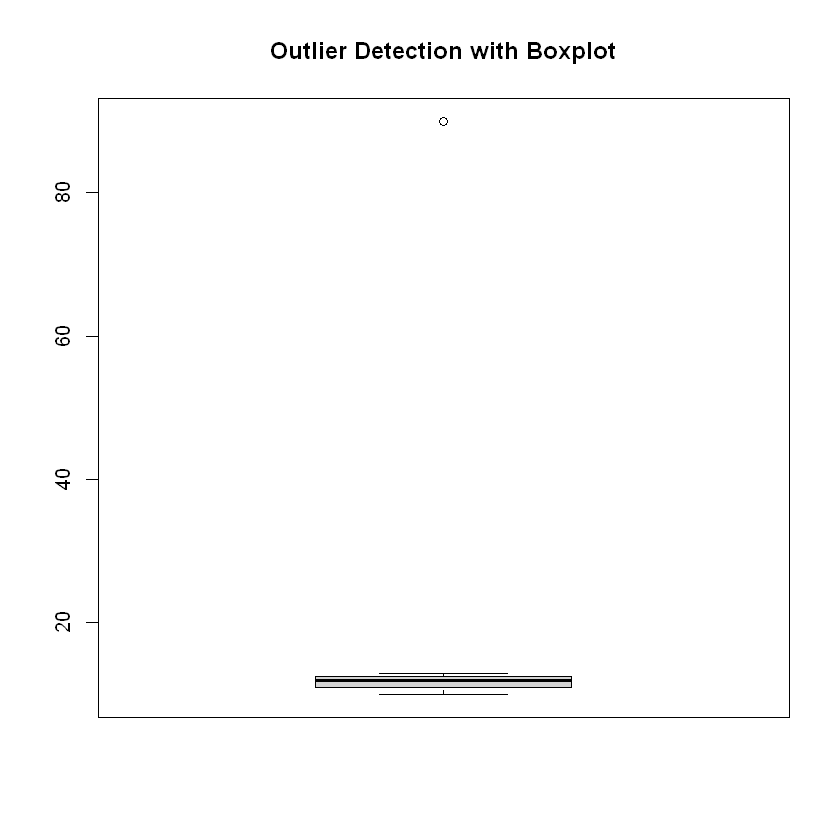

In [5]:
# ---- Missing values ----
sample_df <- data.frame(x = c(1, 2, NA, 4, 5), y = c(NA, 2, 3, 4, 5))

is.na(sample_df)             # logical matrix of missing values
colSums(is.na(sample_df))    # count of NAs per column

# Remove rows with any NA
na.omit(sample_df)

# Replace NA with the column mean
sample_df$x[is.na(sample_df$x)] <- mean(sample_df$x, na.rm = TRUE)
sample_df

# ---- Outliers ----
values <- c(10, 12, 11, 13, 90, 12, 11)

# Using the IQR rule to detect outliers
q1 <- quantile(values, 0.25)
q3 <- quantile(values, 0.75)
iqr <- q3 - q1
lower <- q1 - 1.5 * iqr
upper <- q3 + 1.5 * iqr
outliers <- values[values < lower | values > upper]
outliers

# Boxplot is a quick visual way to spot outliers
boxplot(values, main = "Outlier Detection with Boxplot")


## 6. Data Transformation and Feature Engineering

Feature engineering is the process of creating new, more useful variables from existing ones to improve analysis or model performance.

In [ ]:
df <- mtcars

# Creating new features
df$efficiency <- df$mpg / df$wt          # mpg per unit weight
df$hp_category <- ifelse(df$hp > 150, "High", "Low")

# Scaling / normalization (z-score standardization)
df$mpg_scaled <- scale(df$mpg)

# Log transformation - useful for skewed data
df$log_hp <- log(df$hp)

head(df[, c("mpg", "hp", "efficiency", "hp_category", "mpg_scaled", "log_hp")])


,mpg,hp,efficiency,hp_category,mpg_scaled,log_hp
,<dbl>,<dbl>,<dbl>,<chr>,"<dbl[,1]>",<dbl>
Mazda RX4,21.0,110,8.015267,Low,0.1508848,4.700480
Mazda RX4 Wag,21.0,110,7.304348,Low,0.1508848,4.700480
Datsun 710,22.8,93,9.827586,Low,0.4495434,4.532599
Hornet 4 Drive,21.4,110,6.656299,Low,0.2172534,4.700480
Hornet Sportabout,18.7,175,5.436047,High,-0.2307345,5.164786
Valiant,18.1,105,5.231214,Low,-0.3302874,4.653960


: 

## Practice Exercise

1. Load a data set of your choice and print its structure using `str()`.
2. Use `dplyr` to filter, select, and summarize the data in a single pipeline.
3. Reshape a small wide data set into long format and back again with `tidyr`.
4. Identify and handle both missing values and outliers in a sample data set.


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer